In [426]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os
import xarray as xr
import matplotlib.ticker as ticker


In [458]:
PR = 50
u_file = f"/data92/PeterChang/Dycore_data/PR{PR}/u/PR{PR}_500_20000day_u_6hourly.h5"
v_file = f"/data92/PeterChang/Dycore_data/PR{PR}/v/PR{PR}_500_20000day_v_6hourly.h5"
p_file = f"/data92/PeterChang/Dycore_data/PR{PR}/p/PR{PR}_500_20000day_p_6hourly.h5"

t_file = f"/data92/PeterChang/Dycore_data/PR{PR}/t/PR{PR}_500_20000day_t_6hourly.h5"

In [459]:
with h5py.File(u_file, "r") as ds:
    u = np.asarray(ds["u"][:])

# with h5py.File(v_file, "r") as ds:
#     v = np.asarray(ds["v"][:])

# with h5py.File(t_file, "r") as ds:
#     t = np.asarray(ds["t"][:])

# with h5py.File(p_file, "r") as ds:
#     p = np.asarray(ds["p"][:])

# # with h5py.File(theta_file, "r") as ds:
# #     theta = np.asarray(ds["theta"][:])

In [476]:
u.shape

(78000, 20, 64, 128)

In [477]:
def Cal_EOF_PC_for_barotropic(input_data):
    import sys
    sys.path.append("/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/")
    from EOF import EOF
    # input : (time, y)
    
    # Perform latitude weighting
    input_data_weighted = input_data * np.sqrt(np.cos(np.deg2rad(np.linspace(0, 90, input_data.shape[1]))))

    # Initialize an EOF instance with weighted input data
    n_component = min(input_data.shape[0], input_data.size // input_data.shape[0])

    print("n_component:", n_component)
    eof_instance = EOF((input_data_weighted,), n_components=n_component, field="1D")
    
    # Compute EOFs and PCs
    eof_instance.get()
    
    # Retrieve EOFs and PCs and Extract EOF1, PC1, EOF2, and PC2
    EOF1, EOF2 = eof_instance.EOF[:2]
    PC1, PC2 = eof_instance.PC[:2]

    # Normalize PCs and EOFs
    PC1_norm, PC2_norm = PC1 / PC1.std(), PC2 / PC2.std()
    EOF1_norm, EOF2_norm = EOF1 * PC1.std(), EOF2 * PC2.std()
    
    return EOF1_norm, PC1_norm, EOF2_norm, PC2_norm


In [488]:
EOF1, PC1, EOF2, PC2 = Cal_EOF_PC_for_barotropic(u[:,:,32:].mean(axis=(1,3)))


n_component: 32


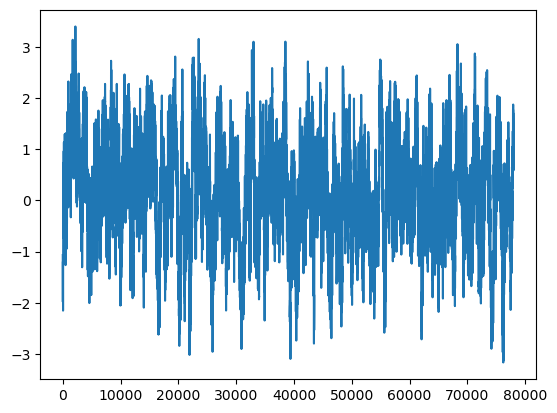

In [500]:
plt.figure()
# plt.plot(EOF1)
plt.plot(PC1)


In [461]:
# def Cal_EOF_PC_for_2D(input_data):
#     import sys
#     sys.path.append("/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/")
#     from EOF import EOF
#     # input : (time, y)
    
#     # Perform latitude weighting
#     input_data_weighted = input_data * np.sqrt(np.cos(np.deg2rad(np.linspace(0, 90, input_data.shape[1]))))

#     # Initialize an EOF instance with weighted input data
#     n_component = min(input_data.shape[0], input_data.size // input_data.shape[0])

#     print("n_component:", n_component)
#     eof_instance = EOF((input_data_weighted,), n_components=n_component, field="1D")
    
#     # Compute EOFs and PCs
#     eof_instance.get()
    
#     # Retrieve EOFs and PCs and Extract EOF1, PC1, EOF2, and PC2
#     EOF1, EOF2 = eof_instance.EOF[:2]
#     PC1, PC2 = eof_instance.PC[:2]

#     # Normalize PCs and EOFs
#     PC1_norm, PC2_norm = PC1 / PC1.std(), PC2 / PC2.std()
#     EOF1_norm, EOF2_norm = EOF1 * PC1.std(), EOF2 * PC2.std()
    
#     return EOF1_norm, PC1_norm, EOF2_norm, PC2_norm


In [462]:
u_2D = u[:,:,32:].mean(axis=(3))

In [463]:
u_2D_reshape = np.reshape(u_2D, [78000, 20*32])

In [464]:
EOF1, PC1, EOF2, PC2 = Cal_EOF_PC_for_2D(u_2D_reshape)


n_component: 640


In [465]:
EOF1.shape

(640,)

In [466]:
EOF1_reshape = EOF1.reshape([20,32])

In [457]:
# EOF1_reshape_PR0 = EOF1_reshape

In [309]:
# EOF1 *= -1
# PC1 *= -1


In [481]:
u.shape

(78000, 20, 64, 128)

In [480]:
EOF1.shape

(32,)

In [482]:
PC1.shape

(78000,)

In [491]:
u_reshape = np.mean(u[:,:,32:,:], axis=(3)).reshape([78000, 20*32])

In [513]:
EOF1_dot = u_reshape.T.dot(PC1) / np.dot(PC1.reshape([1,78000]), (PC1.reshape([78000,1])))


In [514]:
EOF1_dot_reshape = EOF1_dot.reshape([20,32])

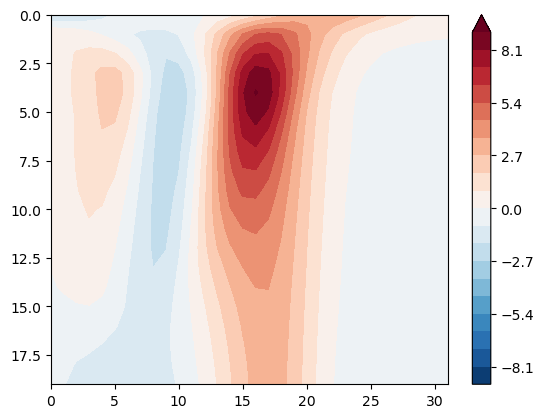

In [518]:
plt.figure()
plt.contourf(EOF1_dot_reshape, levels=np.linspace(-9,9,21), extend="max", cmap="RdBu_r")
plt.colorbar()
plt.gca().invert_yaxis()

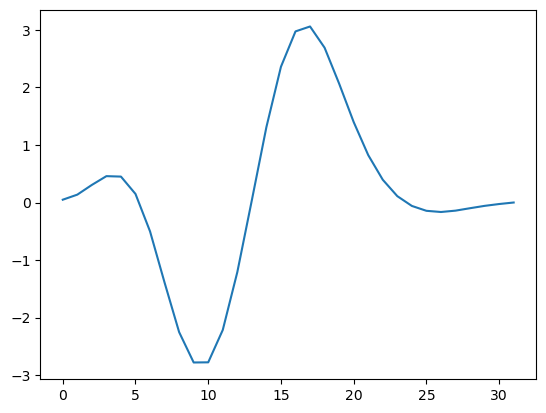

In [487]:
plt.figure()
plt.plot(EOF1)
# plt.plot(EOF1_dot)


In [311]:
time_idx_pos = np.where(PC1 >  PC1.std() * 1 + PC1.mean())
time_idx_neg = np.where(PC1 <  -PC1.std() * 1 + PC1.mean())

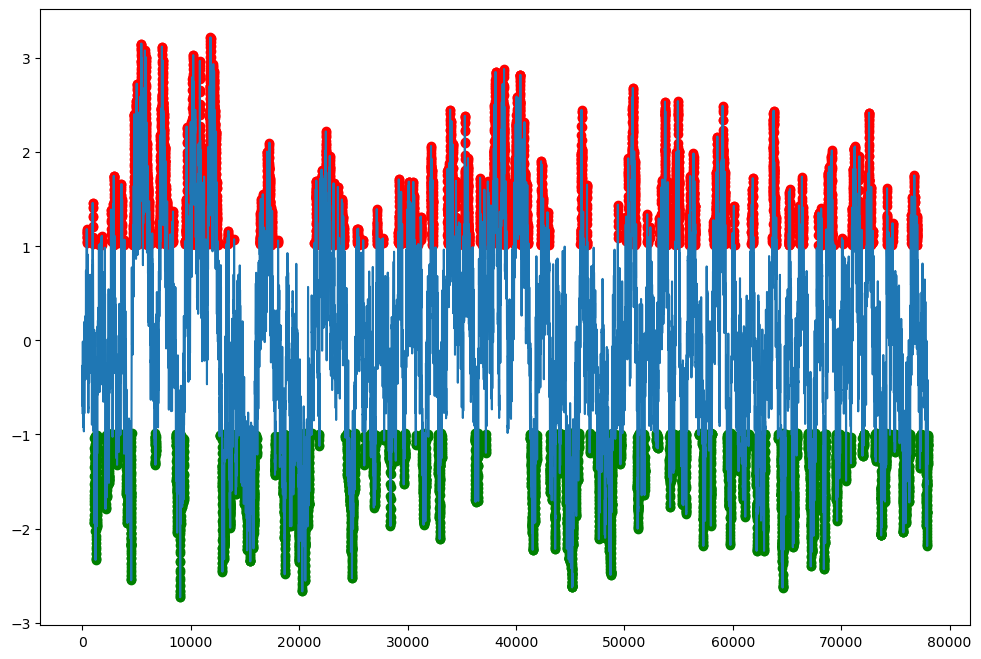

In [315]:
# Select the values from PC1[0] that satisfy the condition
PC1_big = PC1[time_idx_pos]
PC1_sml = PC1[time_idx_neg]

x = np.linspace(0,360,128)
y = np.linspace(-90,90,64)
xx,yy = np.meshgrid(x,y)
days = np.linspace(0,78000,78000)

# Plot the data
plt.figure(figsize=(12,8), dpi=100.)
plt.plot(days, PC1)
plt.scatter(days[time_idx_pos], PC1_big, color="red")

# plt.scatter(days[PC1_big_indices[0]-500], PC1_big, color="Orange")
# plt.scatter(days[PC1_big_indices[0]-50], PC1_50[PC1_big_indices[0]-50], color="Purple")
# plt.scatter(days[PC1_big_indices[0]+100], PC1_50[PC1_big_indices[0]+100], color="Orange")
plt.scatter(days[time_idx_neg], PC1_sml, color="green")
plt.show()


In [340]:
time_idx_pos

array([[  391,   392,   393, ..., 77017, 77018, 77019]])

In [317]:
time_idx_neg_test

array([[ 1090,  1091,  1092, ..., 77995, 77996, 77997]])

In [271]:
# 儲存 positive time index
with h5py.File(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/New_PC1_time_idx/PC1_positive_1std_PR{PR}.h5", 'w') as f:
    f.create_dataset("time_idx_pos", data=time_idx_pos)

# 儲存 negative time index
with h5py.File(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/New_PC1_time_idx/PC1_negative_1std_PR{PR}.h5", 'w') as f:
    f.create_dataset("time_idx_neg", data=time_idx_neg)

In [9]:
# import sys
# sys.path.append('/data92/PeterChang/back_to_master1220/Moist_Dycore/Jucker_Climate/aostools/')

# # from Climate import ComputeEPfluxDiv
# import importlib
# import climate  

# importlib.reload(climate)


<module 'climate' from '/data92/PeterChang/back_to_master1220/Moist_Dycore/Jucker_Climate/aostools/climate.py'>

In [7]:
# lat = np.linspace(-90,90,64)
# pres = p[:1000].mean(axis=(0,2,3))

In [9]:
# ep1, ep2, _, dthdp, vptp = climate.ComputeEPfluxDiv(lat, pres/100, u[:], v[:], t[:])

(20, 64)


In [ ]:
# np.savez(f"epflux_PR{PR}.npz",
#          ep1=ep1,
#          ep2=ep2,
#          dthdp=dthdp,
#          lat=lat,
#          pres=pres,
#          vptp=vptp)
# print("Saving done")

In [69]:
data = np.load("epflux_PR0.npz")
ep1 = data["ep1"]
ep2 = data["ep2"]
lat = data["lat"]
pres = data["pres"]
dthdp = data["dthdp"]
vptp = data["vptp"]


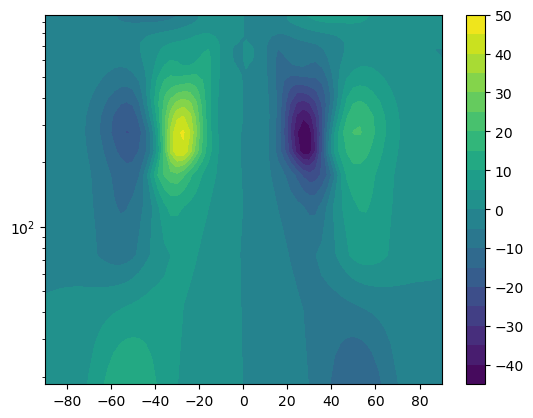

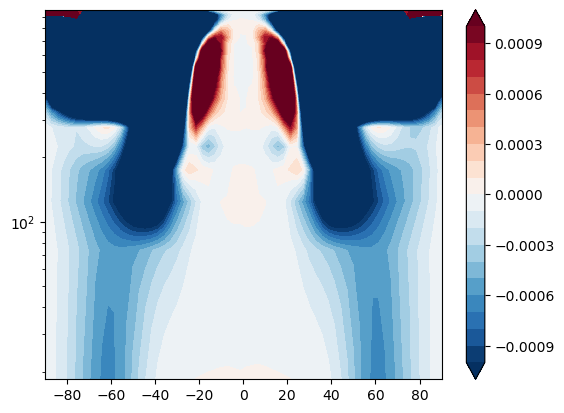

In [70]:
fig, ax = plt.subplots()
CS = ax.contourf(lat, pres/100, np.nanmean(ep1[:], axis=0), levels=21)
plt.colorbar(CS)
ax.set_yscale("log")
# ax.invert_yaxis()

fig, ax = plt.subplots()
CS = ax.contourf(lat, pres/100, np.nanmean(ep2[:], axis=0), levels=np.linspace(-0.001,0.001,21), cmap="RdBu_r", extend="both")
plt.colorbar(CS)
ax.set_yscale("log")
# ax.invert_yaxis()
# ax.set_ylim([100000,0])

In [52]:
# t_bar.shape

NameError: name 't_bar' is not defined

In [71]:
# def set_size(w,h, ax=None):
# 	""" w, h: width, height in inches """
# 	if not ax: ax=plt.gca()
# 	l = ax.figure.subplotpars.left
# 	r = ax.figure.subplotpars.right
# 	t = ax.figure.subplotpars.top
# 	b = ax.figure.subplotpars.bottom
# 	figw = float(w)/(r-l)
# 	figh = float(h)/(t-b)
# 	ax.figure.set_size_inches(figw, figh)

Text(0.5, 1.0, 'EP flux PR50')

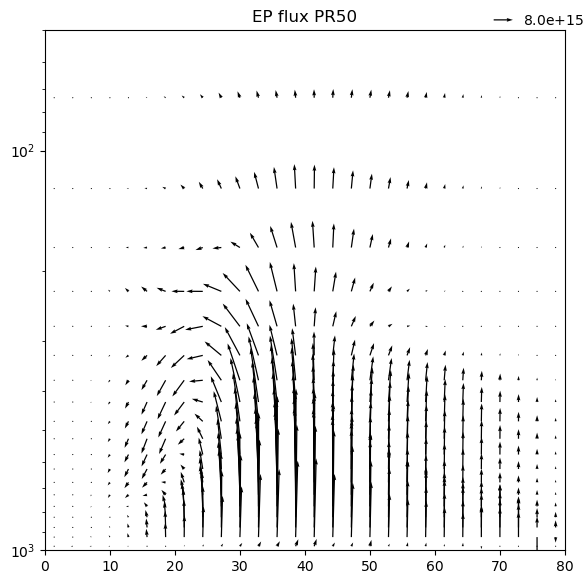

In [72]:
# fig, ax = plt.subplots(1)
# set_size(5.2, 5.2, ax)
# Fphi, Fp = climate.PlotEPfluxArrows(lat, pres/100, np.nanmean(ep1[:], axis=0), np.nanmean(ep2[:], axis=0), fig, ax, scale=80E14, yscale="log")
# plt.xlim([0,80])
# plt.ylim([1000,50])
# plt.title("EP flux PR50")

# All exps

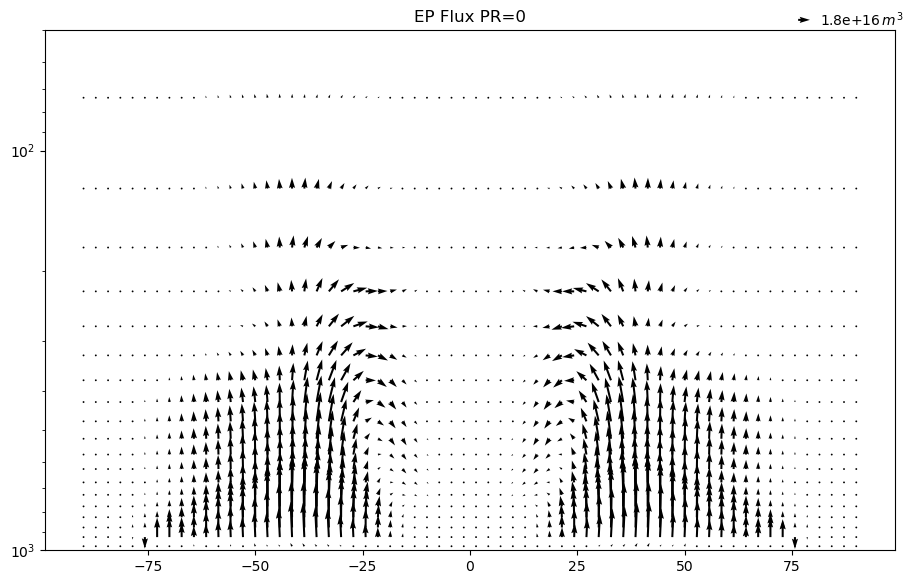

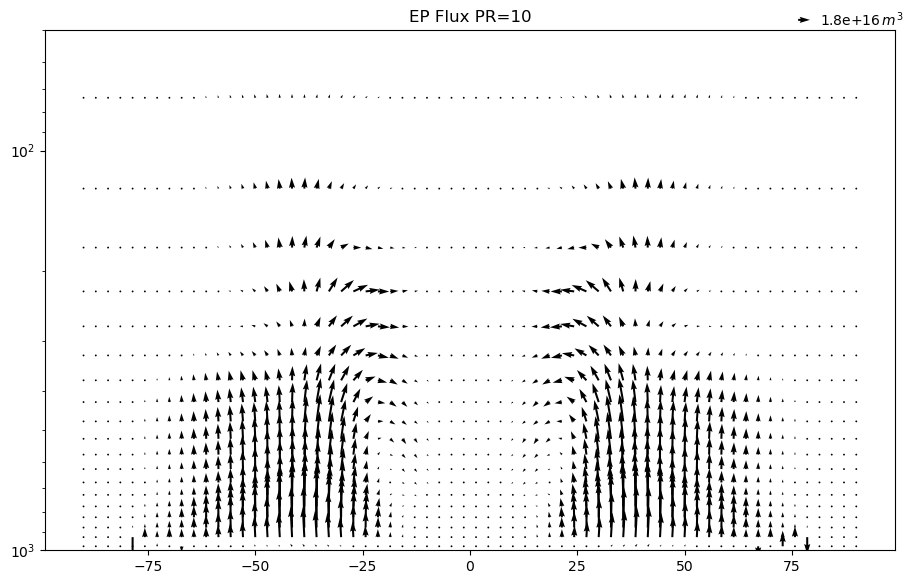

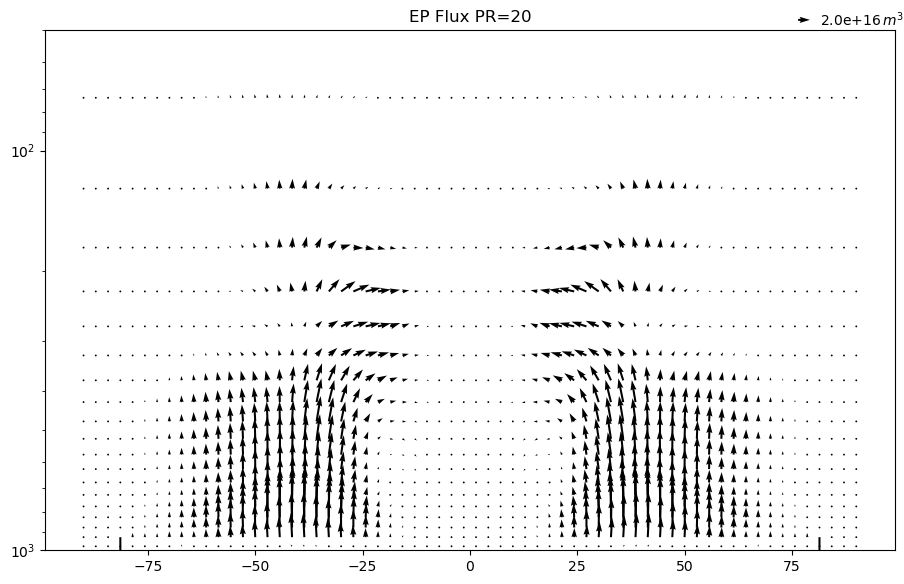

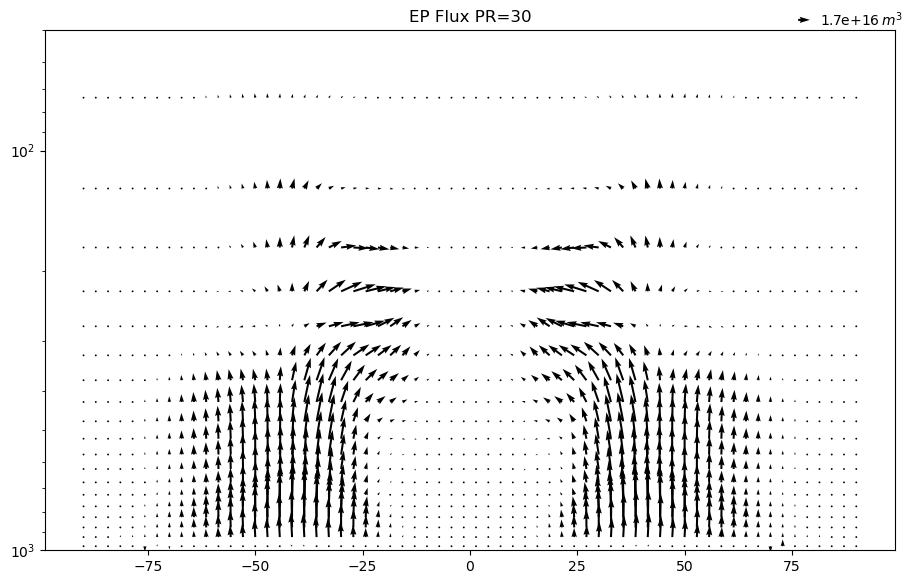

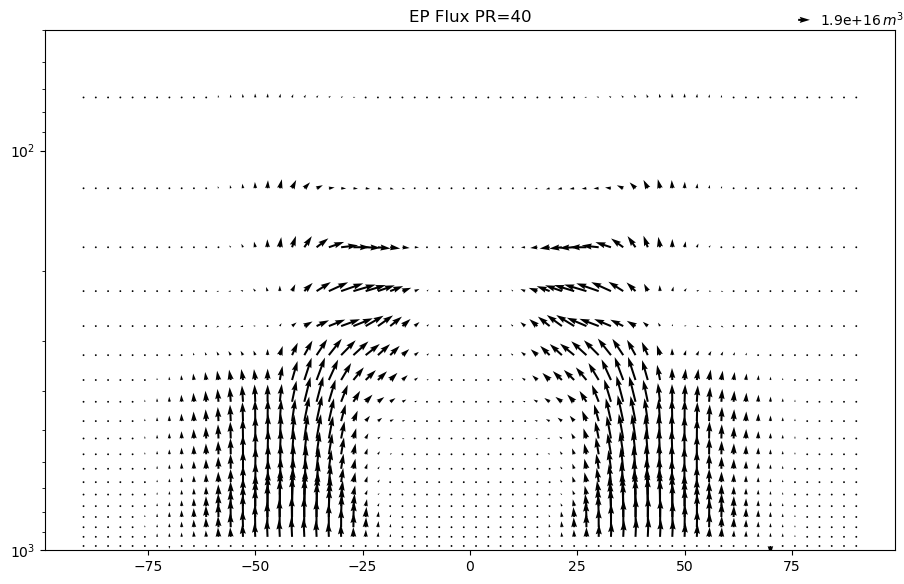

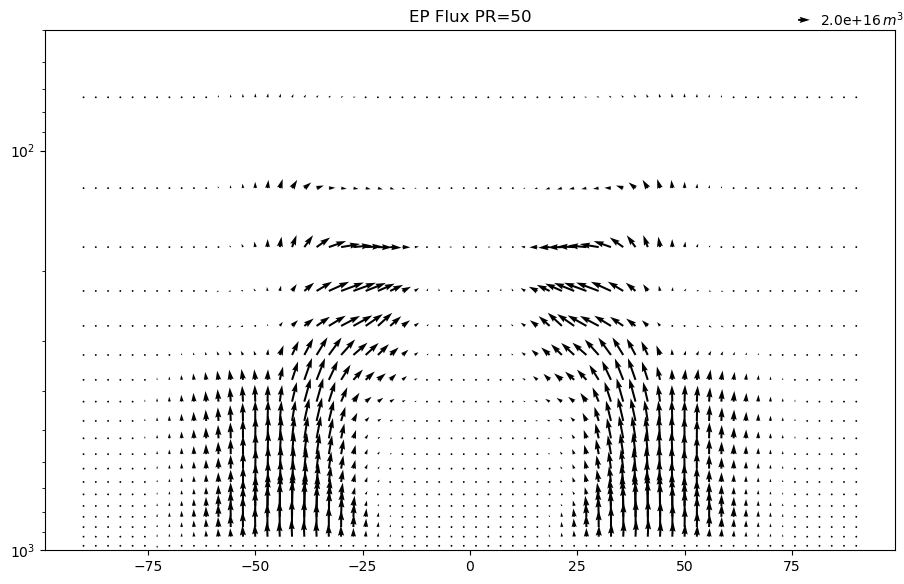

In [393]:
import numpy as np
import matplotlib.pyplot as plt

def set_size(w, h, ax):
    l = ax.figure.subplotpars.left
    r = ax.figure.subplotpars.right
    t = ax.figure.subplotpars.top
    b = ax.figure.subplotpars.bottom
    figw = float(w) / (r - l)
    figh = float(h) / (t - b)
    ax.figure.set_size_inches(figw, figh)

pr_values = [0, 10, 20, 30, 40, 50]
figs = []

for pr in pr_values:
    data = np.load(f"epflux_PR{pr}.npz")
    ep1 = data["ep1"]
    ep2 = data["ep2"]
    lat = data["lat"]
    pres = data["pres"]

    ep1_mean = ep1.mean(axis=0)
    ep2_mean = ep2.mean(axis=0)

    # --- Compute scaled vectors as in PlotEPfluxArrows ---
    a0 = 6376000.0
    g = 9.81
    cosphi = np.cos(np.deg2rad(lat))
    Fphi = 2 * np.pi / g * cosphi**2 * a0**2 * ep1_mean
    Fp   = 2 * np.pi / g * cosphi**2 * a0**3 * ep2_mean

    # Compute magnitude and 90th percentile
    magnitude = np.sqrt(Fphi**2 + Fp**2)
    scale_90 = np.percentile(magnitude, 30)

    # Plot
    fig, ax = plt.subplots(1)
    set_size(8.5, 5.2, ax)

    Fphi_out, Fp_out, = climate.PlotEPfluxArrows(
        lat, pres / 100, ep1_mean, ep2_mean, fig, ax,
        scale=scale_90, yscale="log"
    )

    ax.set_yscale("log")
    # ax.set_xlim([0, 80])
    ax.set_ylim([1000, 50])
    ax.set_title(f"EP Flux PR={pr}")

    figs.append(fig)
    plt.show()


# Composite EP flux with PC1 extreme time index 

In [354]:
# # Re-import necessary libraries after reset
# import os
# import numpy as np
# import xarray as xr
# import h5py

def load_ep_flux_data(pr, save_dir):
    # with h5py.File(f"epflux_PR{pr}.npz", "r") as f:
    f = np.load(f"epflux_PR{pr}.npz", "r")
    print(f.keys())
    Fj = f["ep1"][:]  # (time, level, lat)
    Fk = f["ep2"][:]
    lat = f["lat"][:]
    pres = f["pres"][:]
    return Fj, Fk, lat, pres

def composite_mean(F, time_idx_array, lags):
    samples = []
    for lag in lags:
        time_idx_array_lag = time_idx_array + lag
        time_idx_array_lag = time_idx_array_lag[time_idx_array_lag<F.shape[0]]
        samples.append(F[time_idx_array_lag].mean(axis=0))
    print(len(samples))
    return np.mean(samples, axis=0)
    
def composite_alltime_mean(F):
    return np.mean(F, axis=0)
# Configuration
save_dir = "/data92/PeterChang/back_to_master1220/Moist_Dycore/"

pr_list = [0,10,20,30,40,50]
lags_5_20 = np.arange(5*4, 25*4+1, 1)
lags_30_60 = np.arange(90*4, 100*4+1, 1)

# Output
same_pr_ep_diff = {}

for PR in pr_list:
    print(f"\nLoading EP flux data for PR={PR}...")
    Fj, Fk, latitude, pres = load_ep_flux_data(PR, save_dir)
    print(Fj.shape)

    print(f"Loading time indices for PR={PR}...")
    # time_idx_pos = np.load(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/New_PC1_time_idx/PC1_positive_1std_PR{PR}.npz")
    # time_idx_neg = np.load(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/New_PC1_time_idx/PC1_negative_1std_PR{PR}.npz")
    with h5py.File(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/New_PC1_time_idx/PC1_positive_1std_PR{PR}.h5") as f:
        print(f.keys())  # 看有哪些 key
        time_idx_pos = f["time_idx_pos"][:]
        print(time_idx_pos)

    with h5py.File(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/New_PC1_time_idx/PC1_negative_1std_PR{PR}.h5") as f:
        print(f.keys())  # 看有哪些 key
        time_idx_neg = f["time_idx_neg"][:]

    
    ep1_ref = composite_alltime_mean(Fj)
    ep2_ref = composite_alltime_mean(Fk)
    
    # print(time_idx_pos.shape)
    # print(time_idx_neg.shape)
    
    print("--> Computing EP+ composite...")
    ep1_pos = composite_mean(Fj, time_idx_pos, lags_5_20)
    ep2_pos = composite_mean(Fk, time_idx_pos, lags_5_20)
    ep1_far_pos = composite_mean(Fj, time_idx_pos, lags_30_60)
    ep2_far_pos = composite_mean(Fk, time_idx_pos, lags_30_60)

    EP_plus   = ep1_pos - ep1_far_pos
    EP_plus_p = ep2_pos - ep2_far_pos

    print("--> Computing EP- composite...")
    ep1_neg = composite_mean(Fj, time_idx_neg, lags_5_20)
    ep2_neg = composite_mean(Fk, time_idx_neg, lags_5_20)
    ep1_far_neg = composite_mean(Fj, time_idx_neg, lags_30_60)
    ep2_far_neg = composite_mean(Fk, time_idx_neg, lags_30_60)

    EP_minus   = ep1_neg - ep1_far_neg
    EP_minus_p = ep2_neg - ep2_far_neg

    diff_phi = EP_plus   - EP_minus
    diff_p   = EP_plus_p - EP_minus_p

    same_pr_ep_diff[PR] = (diff_phi, diff_p)

    # Create xarray Dataset and save
    level = pres # np.linspace(1000, 100000, diff_phi.shape[0])
    lat = latitude # np.linspace(-90, 90, diff_phi.shape[1])
    ds = xr.Dataset({
        f"EP_phi_diff_PR{PR}": (["level", "lat"], diff_phi),
        f"EP_p_diff_PR{PR}":   (["level", "lat"], diff_p),
        f"ep1_pos":   (["level", "lat"], ep1_pos),
        f"ep2_pos":   (["level", "lat"], ep2_pos),

        f"ep1_neg":   (["level", "lat"], ep1_neg),
        f"ep2_neg":   (["level", "lat"], ep2_neg),
        
        f"ep1_ref":   (["level", "lat"], ep1_ref),
        f"ep2_ref":   (["level", "lat"], ep2_ref),
        
        
    }, coords={"level": level, "lat": lat})

    save_path = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/same_pr_ep_diff_PR{PR}.nc"
    print(f"Saving composite diff to {save_path}...")
    ds.to_netcdf(save_path)
    print("✓ Save complete.")



Loading EP flux data for PR=0...
KeysView(NpzFile 'epflux_PR0.npz' with keys: ep1, ep2, dthdp, lat, pres...)
(78000, 20, 64)
Loading time indices for PR=0...
<KeysViewHDF5 ['time_idx_pos']>
[[  391   392   393 ... 77017 77018 77019]]
<KeysViewHDF5 ['time_idx_neg']>
--> Computing EP+ composite...
81
81
41
41
--> Computing EP- composite...
81
81
41
41
Saving composite diff to /data92/PeterChang/back_to_master1220/Moist_Dycore/same_pr_ep_diff_PR0.nc...
✓ Save complete.

Loading EP flux data for PR=10...
KeysView(NpzFile 'epflux_PR10.npz' with keys: ep1, ep2, dthdp, lat, pres...)
(78000, 20, 64)
Loading time indices for PR=10...
<KeysViewHDF5 ['time_idx_pos']>
[[  780   781   782 ... 77843 77844 77845]]
<KeysViewHDF5 ['time_idx_neg']>
--> Computing EP+ composite...
81
81
41
41
--> Computing EP- composite...
81
81
41
41
Saving composite diff to /data92/PeterChang/back_to_master1220/Moist_Dycore/same_pr_ep_diff_PR10.nc...
✓ Save complete.

Loading EP flux data for PR=20...
KeysView(NpzFile 

In [343]:
ep1_pos.shape

(20, 64)

In [344]:
# PR = 0
# with np.load(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/New_PC1_time_idx/PC1_positive_1std_PR{PR}.npz") as npzfile:
#     print(npzfile.files)  # 看有哪些 key
#     time_idx_pos = npzfile["time_idx_pos"]

# with np.load(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/New_PC1_time_idx/PC1_negative_1std_PR{PR}.npz") as npzfile:
#     print(npzfile.files)  # 看有哪些 key
#     time_idx_neg = npzfile["time_idx_neg"]

<KeysViewHDF5 ['EP_p_diff_PR0', 'EP_phi_diff_PR0', 'ep1_neg', 'ep1_pos', 'ep1_ref', 'ep2_neg', 'ep2_pos', 'ep2_ref', 'lat', 'level']>
0.0
<KeysViewHDF5 ['EP_p_diff_PR10', 'EP_phi_diff_PR10', 'ep1_neg', 'ep1_pos', 'ep1_ref', 'ep2_neg', 'ep2_pos', 'ep2_ref', 'lat', 'level']>
7.3314304
<KeysViewHDF5 ['EP_p_diff_PR20', 'EP_phi_diff_PR20', 'ep1_neg', 'ep1_pos', 'ep1_ref', 'ep2_neg', 'ep2_pos', 'ep2_ref', 'lat', 'level']>
4.633728
<KeysViewHDF5 ['EP_p_diff_PR30', 'EP_phi_diff_PR30', 'ep1_neg', 'ep1_pos', 'ep1_ref', 'ep2_neg', 'ep2_pos', 'ep2_ref', 'lat', 'level']>
5.144327
<KeysViewHDF5 ['EP_p_diff_PR40', 'EP_phi_diff_PR40', 'ep1_neg', 'ep1_pos', 'ep1_ref', 'ep2_neg', 'ep2_pos', 'ep2_ref', 'lat', 'level']>
8.4146805
<KeysViewHDF5 ['EP_p_diff_PR50', 'EP_phi_diff_PR50', 'ep1_neg', 'ep1_pos', 'ep1_ref', 'ep2_neg', 'ep2_pos', 'ep2_ref', 'lat', 'level']>
10.129669


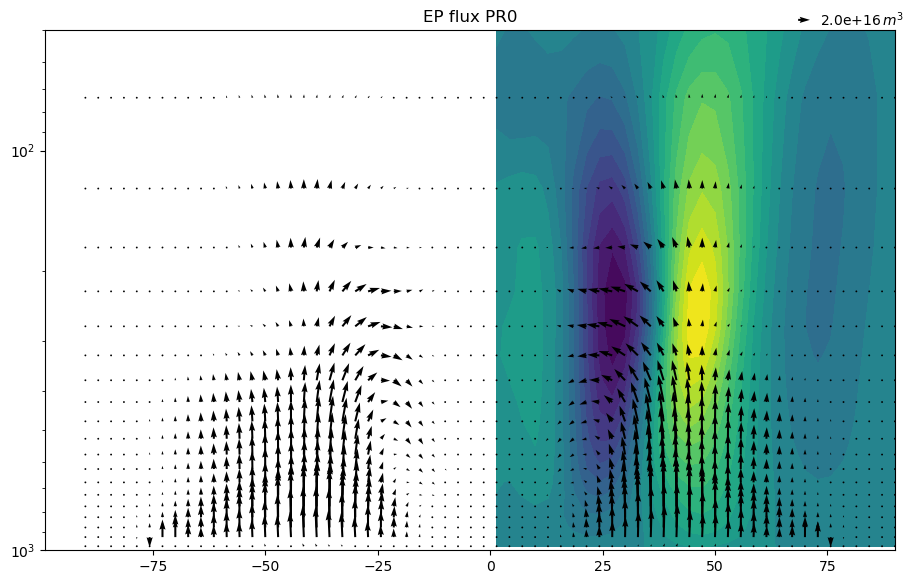

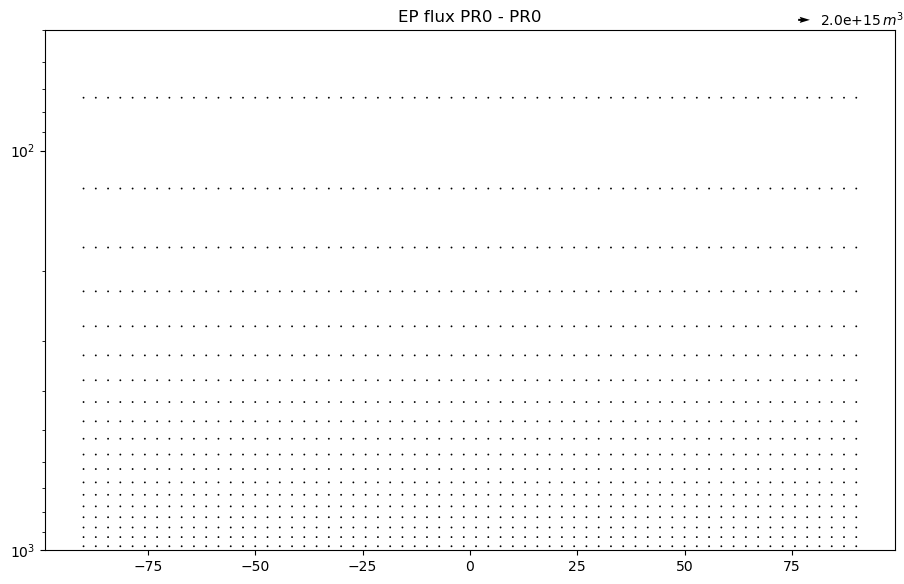

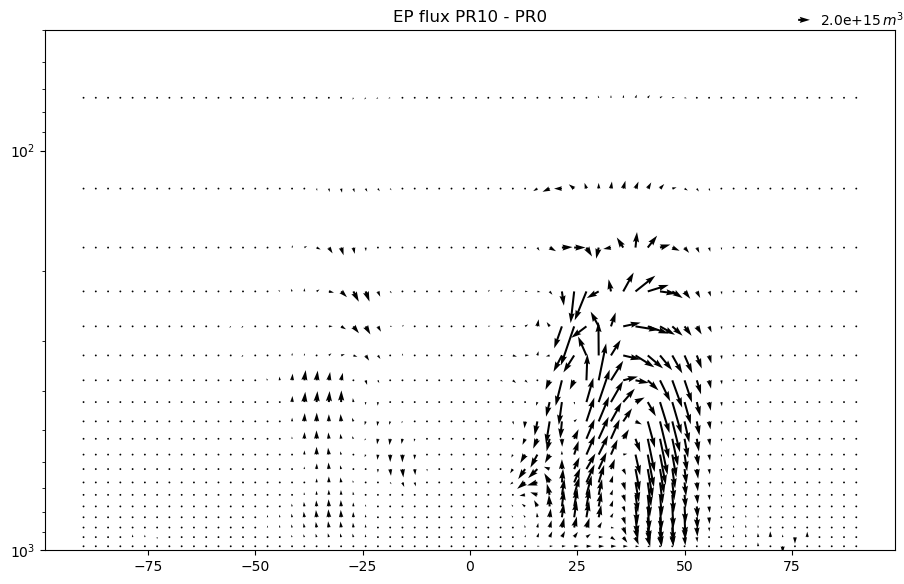

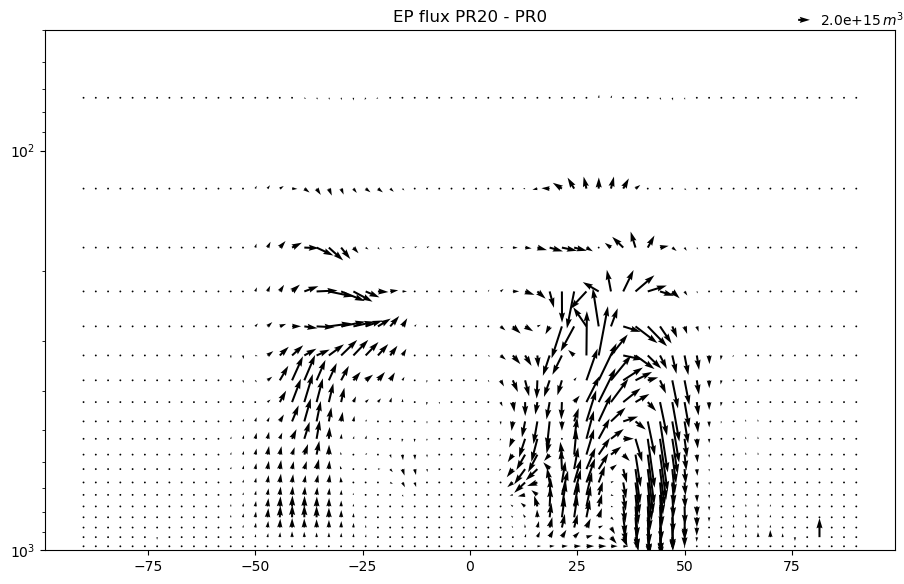

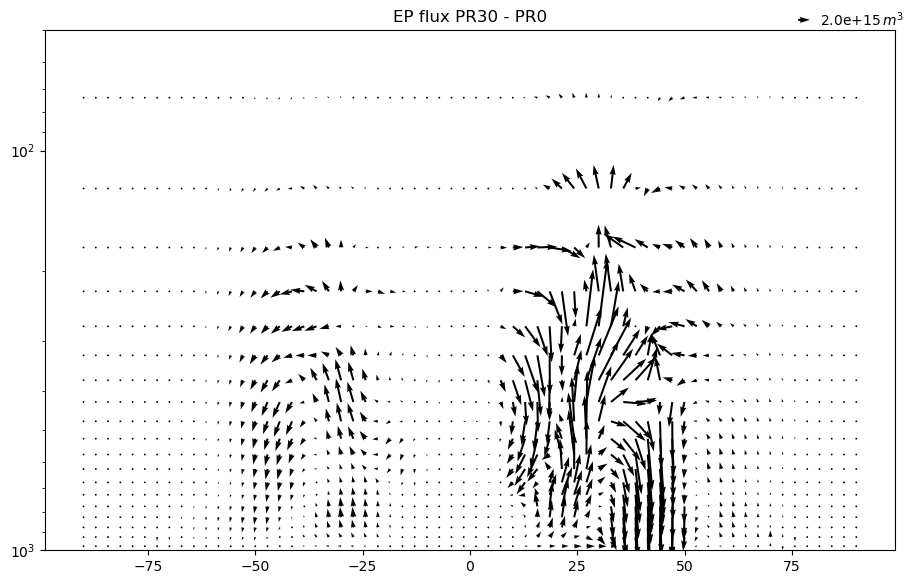

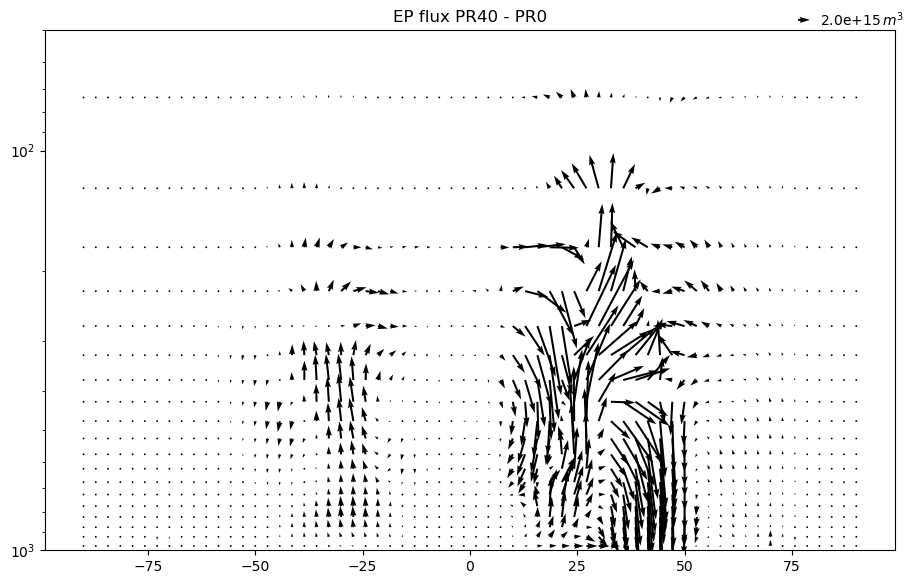

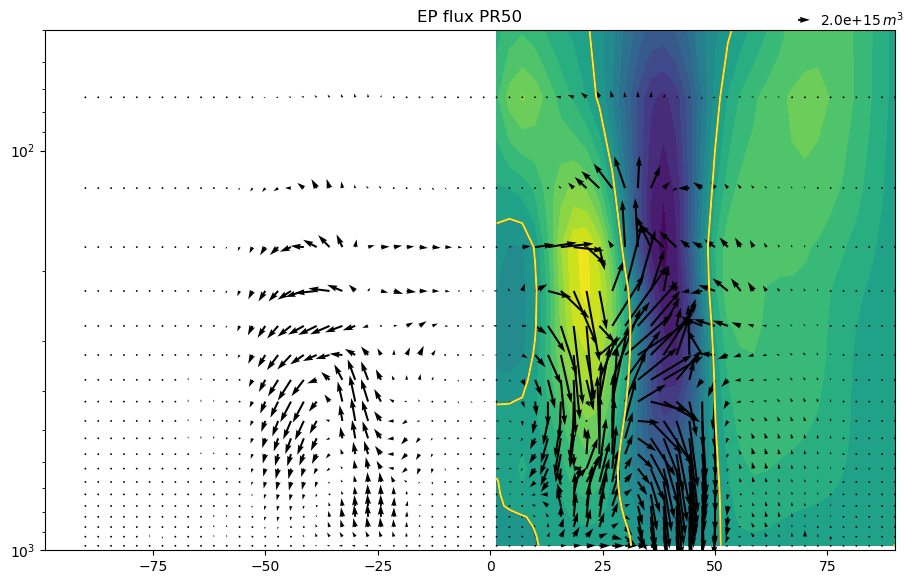

In [475]:


# fig, ax = plt.subplots(1)
# set_size(5.2, 5.2, ax)
# Fphi, Fp = climate.PlotEPfluxArrows(lat, pres/100, (ep1_ref), (ep2_ref), fig, ax, scale=190E14, yscale="log")
# plt.xlim([0,80])
# plt.ylim([1000,50])
# plt.title("EP flux PR50")
import sys
sys.path.append('/data92/PeterChang/back_to_master1220/Moist_Dycore/Jucker_Climate/aostools/')

# from Climate import ComputeEPfluxDiv
import importlib
import climate  

importlib.reload(climate)


for PR in range(0,60,10):
    with h5py.File(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/same_pr_ep_diff_PR{PR}.nc", "r") as f:
        print(f.keys())
        
        diff_phi_new = f[f"EP_phi_diff_PR{PR}"][:]
        diff_p_new   = f[f"EP_p_diff_PR{PR}"][:]
        ep1_pos = f["ep1_pos"][:]
        ep2_pos = f["ep2_pos"][:]

        ep1_neg = f["ep1_neg"][:]
        ep2_neg = f["ep2_neg"][:]

        ep1_ref = f["ep1_ref"][:]
        ep2_ref = f["ep2_ref"][:]
        
        lat = f["lat"][:]
        level = f["level"][:]

        if PR ==0:
            diff_phi_new_PR0 = diff_phi_new # ep1_pos - ep1_ref
            diff_p_new_PR0   = diff_p_new # ep2_pos - ep2_ref
            ep1_pos_PR0 = ep1_pos - ep1_neg
            ep2_pos_PR0 = ep2_pos - ep2_neg

        print((diff_phi_new - diff_phi_new_PR0).max())
        if PR == 0:
            fig, ax = plt.subplots(1)
            set_size(8.5, 5.2, ax)
            # Fphi, Fp = climate.PlotEPfluxArrows(lat, level/100, (ep1_pos - ep1_neg - ep1_ref), (ep2_pos - ep2_neg- ep2_ref), fig, ax, scale=20E15, yscale="log")
            # Fphi, Fp = climate.PlotEPfluxArrows(lat, level/100, (ep1_neg), (ep2_neg), fig, ax, scale=20E15, yscale="log")
            plt.contourf(lat[32:], level/100, EOF1_reshape_PR0, levels=21)
            Fphi, Fp = climate.PlotEPfluxArrows(lat, level/100, (ep1_pos), (ep2_pos), fig, ax, scale=20E15, yscale="log")

            # plt.xlim([0,80])
            plt.ylim([1000,50])
            plt.title(f"EP flux PR{PR}")
        if PR == 50:
            fig, ax = plt.subplots(1)
            set_size(8.5, 5.2, ax)
            # Fphi, Fp = climate.PlotEPfluxArrows(lat, level/100, (ep1_pos - ep1_neg - ep1_ref), (ep2_pos - ep2_neg- ep2_ref), fig, ax, scale=20E15, yscale="log")
            # Fphi, Fp = climate.PlotEPfluxArrows(lat, level/100, (ep1_neg), (ep2_neg), fig, ax, scale=20E15, yscale="log")
            plt.contourf(lat[32:], level/100, (-EOF1_reshape - EOF1_reshape_PR0), levels=21)
            plt.contour(lat[32:], level/100, (-EOF1_reshape - EOF1_reshape_PR0), levels=[0,0.001])
            
            Fphi, Fp = climate.PlotEPfluxArrows(lat, level/100, (ep1_pos - ep1_neg - ep1_pos_PR0), (ep2_pos - ep2_neg - ep2_pos_PR0), fig, ax, scale=20E14, yscale="log")

            # plt.xlim([0,80])
            plt.ylim([1000,50])
            plt.title(f"EP flux PR{PR}")
        else:
            fig, ax = plt.subplots(1)
            set_size(8.5, 5.2, ax)
            # Fphi, Fp = climate.PlotEPfluxArrows(lat, level/100, (diff_phi_new - diff_phi_new_PR0), (diff_p_new - diff_p_new_PR0), fig, ax, scale=20E14, yscale="log")
            Fphi, Fp = climate.PlotEPfluxArrows(lat, level/100, (ep1_pos - ep1_neg - ep1_pos_PR0), (ep2_pos - ep2_neg - ep2_pos_PR0), fig, ax, scale=20E14, yscale="log")
            # plt.xlim([0,80])
            plt.ylim([1000,50])
            plt.title(f"EP flux PR{PR} - PR0")

        

In [29]:
def load_ep_flux_data_same_pr(pr, save_dir):
    with h5py.File(os.path.join(save_dir, f"same_pr_ep_diff_PR{pr}.nc"), "r") as f:
        print(f.keys())
        Fj = f[f"EP_p_diff_PR{pr}"][:]  # (time, level, lat)
        Fk = f[f"EP_phi_diff_PR{pr}"][:]
    return Fj, Fk

In [41]:
def load_ep_flux_data(pr, save_dir):
    # with h5py.File(os.path.join(save_dir, f"epflux_PR{pr}.h5"), "r") as f:
    f = np.load(f"epflux_PR{pr}.npz", "r")
    print(f.keys())
    Fj = f["ep1"][:]  # (time, level, lat)
    Fk = f["ep2"][:]
    level = f["pres"][:]
    # time  = f["time"][:]
    return Fj, Fk, level#, time

In [58]:
save_dir_same_pr = "/data92/PeterChang/back_to_master1220/Moist_Dycore/"

# pr = 0
Fj_pr0, Fk_pr0   = load_ep_flux_data_same_pr(0, save_dir_same_pr)
Fj_pr10, Fk_pr10 = load_ep_flux_data_same_pr(10, save_dir_same_pr)
Fj_pr20, Fk_pr20 = load_ep_flux_data_same_pr(20, save_dir_same_pr)
Fj_pr30, Fk_pr30 = load_ep_flux_data_same_pr(30, save_dir_same_pr)
Fj_pr40, Fk_pr40 = load_ep_flux_data_same_pr(40, save_dir_same_pr)
Fj_pr50, Fk_pr50 = load_ep_flux_data_same_pr(50, save_dir_same_pr)




<KeysViewHDF5 ['EP_p_diff_PR0', 'EP_phi_diff_PR0', 'lat', 'level']>
<KeysViewHDF5 ['EP_p_diff_PR10', 'EP_phi_diff_PR10', 'lat', 'level']>
<KeysViewHDF5 ['EP_p_diff_PR20', 'EP_phi_diff_PR20', 'lat', 'level']>
<KeysViewHDF5 ['EP_p_diff_PR30', 'EP_phi_diff_PR30', 'lat', 'level']>
<KeysViewHDF5 ['EP_p_diff_PR40', 'EP_phi_diff_PR40', 'lat', 'level']>
<KeysViewHDF5 ['EP_p_diff_PR50', 'EP_phi_diff_PR50', 'lat', 'level']>


In [55]:
Fj_pr0.shape

(20, 64)

In [56]:
# save_dir = "/data92/PeterChang/back_to_master1220/Moist_Dycore/epflux_result_Jucker/"
# Fj_pr0, Fk_pr0, level   = load_ep_flux_data(0, save_dir)
# Fj_pr10, Fk_pr10, level = load_ep_flux_data(10, save_dir)
# Fj_pr20, Fk_pr20, level = load_ep_flux_data(20, save_dir)
# Fj_pr30, Fk_pr30, level = load_ep_flux_data(30, save_dir)
# Fj_pr40, Fk_pr40, level = load_ep_flux_data(40, save_dir)
# Fj_pr50, Fk_pr50, level = load_ep_flux_data(50, save_dir)

KeysView(NpzFile 'epflux_PR0.npz' with keys: ep1, ep2, dthdp, lat, pres...)
KeysView(NpzFile 'epflux_PR10.npz' with keys: ep1, ep2, dthdp, lat, pres...)
KeysView(NpzFile 'epflux_PR20.npz' with keys: ep1, ep2, dthdp, lat, pres...)
KeysView(NpzFile 'epflux_PR30.npz' with keys: ep1, ep2, dthdp, lat, pres...)
KeysView(NpzFile 'epflux_PR40.npz' with keys: ep1, ep2, dthdp, lat, pres...)
KeysView(NpzFile 'epflux_PR50.npz' with keys: ep1, ep2, dthdp, lat, pres...)


In [57]:
Fj_pr0.shape


(78000, 20, 64)

In [59]:
Fj_mean_pr0 = Fj_pr0#.mean(axis=0)
Fk_mean_pr0 = Fk_pr0#.mean(axis=0)

Fj_mean_pr10 = Fj_pr10#.mean(axis=0)
Fk_mean_pr10 = Fk_pr10#.mean(axis=0)

Fj_mean_pr20 = Fj_pr20#.mean(axis=0)
Fk_mean_pr20 = Fk_pr20#.mean(axis=0)

Fj_mean_pr30 = Fj_pr30#.mean(axis=0)
Fk_mean_pr30 = Fk_pr30#.mean(axis=0)

Fj_mean_pr40 = Fj_pr40#.mean(axis=0)
Fk_mean_pr40 = Fk_pr40#.mean(axis=0)

Fj_mean_pr50 = Fj_pr50#.mean(axis=0)
Fk_mean_pr50 = Fk_pr50#.mean(axis=0)
# Fj_mean = Fj_pr0
# Fk_mean = Fk_pr0



In [60]:
Fj_mean_diff_pr10 = Fj_mean_pr10 - Fj_mean_pr0
Fk_mean_diff_pr10 = Fk_mean_pr10 - Fk_mean_pr0

Fj_mean_diff_pr20 = Fj_mean_pr20 - Fj_mean_pr0
Fk_mean_diff_pr20 = Fk_mean_pr20 - Fk_mean_pr0

Fj_mean_diff_pr30 = Fj_mean_pr30 - Fj_mean_pr0
Fk_mean_diff_pr30 = Fk_mean_pr30 - Fk_mean_pr0

Fj_mean_diff_pr40 = Fj_mean_pr40 - Fj_mean_pr0
Fk_mean_diff_pr40 = Fk_mean_pr40 - Fk_mean_pr0

Fj_mean_diff_pr50 = Fj_mean_pr50 - Fj_mean_pr0
Fk_mean_diff_pr50 = Fk_mean_pr50 - Fk_mean_pr0


Text(0.5, 1.0, 'EP flux PR50')

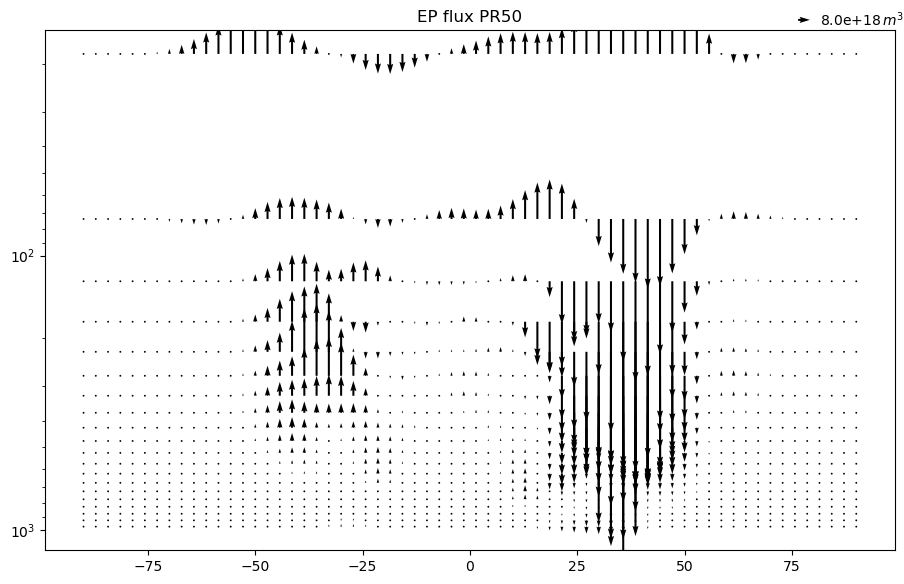

In [68]:
# 1. 根據 EP flux 的 magnitude 決定箭頭代表的單位
magnitude = np.sqrt(Fj_mean_diff_pr10**2 + Fk_mean_diff_pr10**2)
ref_arrow_size = np.nanpercentile(magnitude, 90)  # 第90百分位箭頭作為參考箭頭

# 2. quiver scale 控制「箭頭畫多長」
quiver_scale = 20 * ref_arrow_size  # 調這個會改箭頭長度（越大箭越短）

# # 3. Plot
# y = np.linspace(-90,90,64)
# z_nor = np.linspace(0,1,20)
# yy, zz = np.meshgrid(y, z_nor)
      
# fig, ax = plt.subplots(1, figsize=(8, 6), dpi=100)
# wind_plt = ax.quiver(
#     yy[::, ::], zz[::, ::],
#     Fj_mean_diff_pr10[::, ::], Fk_mean_diff_pr10[::, ::],
#     color="black", width=3e-3, scale=quiver_scale
# )

# # 4. Quiver key，只是圖例，不改數值
# ax.quiverkey(
#     wind_plt, X=0.85, Y=1.01,
#     U=ref_arrow_size,
#     label=f"{ref_arrow_size:.0f} $m^2/s^2$",
#     labelpos='N', labelsep=0.05, color='black'
# )
# ax.set_yscale("log")
# plt.gca().invert_yaxis()
# # ax.set_xlim([0, 90])
# ax.set_xlabel("Latitude")
# ax.set_ylabel("Normalized vertical level")
# plt.title("EP Flux (true scale, visually tuned arrows)")
# plt.tight_layout()
# plt.show()
fig, ax = plt.subplots(1)
set_size(8.5, 5.2, ax)
Fphi, Fp = climate.PlotEPfluxArrows(lat, pres/100, Fj_pr0, Fk_pr0, fig, ax, scale=80E17, yscale="log")
# plt.xlim([0,80])
# plt.ylim([1000,50])
plt.title("EP flux PR50")